# When Models Don't Know What They Don't Know
## Domain Shift and Uncertainty Estimation in Medical Image Classification

---

### Motivation

A deep learning model that performs well in the lab can fail silently in the clinic.  
The problem is not just that the model makes mistakes — it is that it makes mistakes **confidently**.

This is the domain shift problem: a model trained on data from one distribution (one hospital, one scanner, one staining protocol) is deployed on data from a different distribution, and no one notices until harm is done.

In this notebook we demonstrate four things:

1. **How domain shift silently degrades performance** — a model trained on colorectal cancer histology patches (PathMNIST) is evaluated on kidney tissue microscopy images (TissueMNIST). Both are tissue images. The model has never been told it is out of distribution.
2. **How a naive model gives high-confidence wrong predictions** — standard softmax confidence scores are not reliable uncertainty estimates.
3. **How Monte Carlo Dropout provides meaningful uncertainty estimates** — high variance across stochastic forward passes signals that the model genuinely does not know.
4. **How Grad-CAM reveals what the model attends to** — making the failure mode interpretable.

---

### Datasets

- **PathMNIST** (source domain): H&E stained colorectal cancer histology patches, 9 tissue classes, RGB. From NCT-CRC-HE-100K.
- **TissueMNIST** (target domain): Human kidney cortex microscopy, 8 cell/tissue types, grayscale. From the Human Protein Atlas.

Both contain tissue images at cellular scale. The shift arises from different organs, staining protocols, and imaging modalities — the kind of shift that occurs in real clinical deployment.

## 0. Setup

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, models

import medmnist
from medmnist import PathMNIST, TissueMNIST, INFO

import warnings
warnings.filterwarnings('ignore')

os.makedirs('figures', exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'MedMNIST version: {medmnist.__version__}')

Device: cpu
MedMNIST version: 3.0.2


## 1. Load Data

In [3]:
transform_path = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# TissueMNIST is grayscale; replicate to 3 channels to match model input
transform_tissue = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1) if x.shape[0] == 1 else x),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

path_train  = PathMNIST(split='train', transform=transform_path,   download=True)
path_val    = PathMNIST(split='val',   transform=transform_path,   download=True)
path_test   = PathMNIST(split='test',  transform=transform_path,   download=True)
tissue_test = TissueMNIST(split='test', transform=transform_tissue, download=True)

N_TRAIN, N_VAL, N_TEST = 8000, 1000, 1000

path_train_sub  = Subset(path_train,  torch.randperm(len(path_train))[:N_TRAIN])
path_val_sub    = Subset(path_val,    torch.randperm(len(path_val))[:N_VAL])
path_test_sub   = Subset(path_test,   torch.randperm(len(path_test))[:N_TEST])
tissue_test_sub = Subset(tissue_test, torch.randperm(len(tissue_test))[:N_TEST])

train_loader  = DataLoader(path_train_sub,  batch_size=64, shuffle=True,  num_workers=2)
val_loader    = DataLoader(path_val_sub,    batch_size=64, shuffle=False, num_workers=2)
source_loader = DataLoader(path_test_sub,   batch_size=64, shuffle=False, num_workers=2)
target_loader = DataLoader(tissue_test_sub, batch_size=64, shuffle=False, num_workers=2)

N_CLASSES     = len(INFO['pathmnist']['label'])
SOURCE_LABELS = INFO['pathmnist']['label']
TARGET_LABELS = INFO['tissuemnist']['label']

print(f"Source (PathMNIST):   {N_TRAIN} train | {N_VAL} val | {N_TEST} test | {N_CLASSES} classes")
print(f"Target (TissueMNIST): {N_TEST} test | {len(TARGET_LABELS)} classes")

100%|██████████| 206M/206M [01:10<00:00, 2.93MB/s]
100%|██████████| 125M/125M [00:08<00:00, 14.9MB/s]


Source (PathMNIST):   8000 train | 1000 val | 1000 test | 9 classes
Target (TissueMNIST): 1000 test | 8 classes


### 1.1 Visualize the Domain Gap

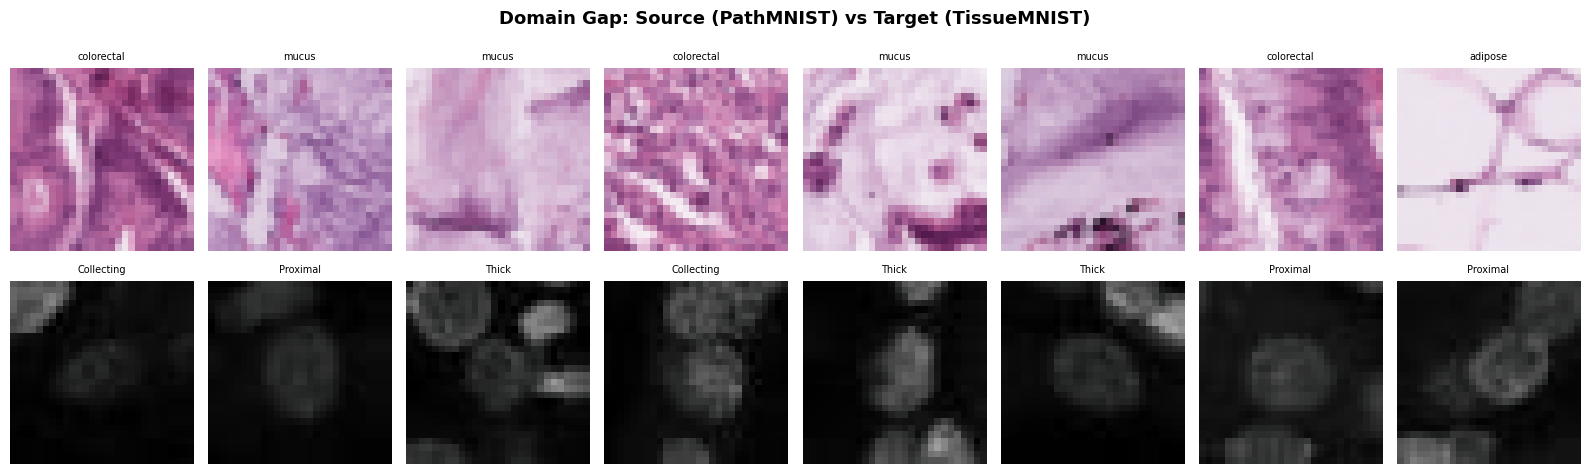

In [4]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Domain Gap: Source (PathMNIST) vs Target (TissueMNIST)',
             fontsize=13, fontweight='bold')

for i in range(8):
    img, label = path_test[i]
    axes[0, i].imshow(denormalize(img).permute(1,2,0).numpy())
    axes[0, i].set_title(SOURCE_LABELS[str(label.item())].split()[0], fontsize=7)
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Source\n(PathMNIST)', fontsize=9, rotation=90, labelpad=40)

for i in range(8):
    img, label = tissue_test[i]
    axes[1, i].imshow(denormalize(img).permute(1,2,0).numpy())
    axes[1, i].set_title(TARGET_LABELS[str(label.item())].split()[0], fontsize=7)
    axes[1, i].axis('off')
axes[1, 0].set_ylabel('Target\n(TissueMNIST)', fontsize=9, rotation=90, labelpad=40)

plt.tight_layout()
plt.savefig('figures/domain_gap.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Model: ResNet-18 with Monte Carlo Dropout

We add dropout before the final classifier and keep it **active at inference time**.  
Running T stochastic forward passes gives a distribution over predictions —  
high variance = high uncertainty. (Gal & Ghahramani, 2016)

In [5]:
class ResNetMCDropout(nn.Module):
    def __init__(self, n_classes, dropout_p=0.3):
        super().__init__()
        self.backbone = models.resnet18(weights='IMAGENET1K_V1')
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(in_features, n_classes)
        )

    def forward(self, x):
        return self.backbone(x)

    def enable_dropout(self):
        for m in self.modules():
            if isinstance(m, nn.Dropout):
                m.train()

    def predict_with_uncertainty(self, x, T=30):
        self.eval()
        self.enable_dropout()
        probs_list = []
        with torch.no_grad():
            for _ in range(T):
                probs = F.softmax(self.forward(x), dim=1)
                probs_list.append(probs.unsqueeze(0))
        all_probs = torch.cat(probs_list, dim=0)  # [T, batch, n_classes]
        mean_probs  = all_probs.mean(dim=0)
        uncertainty = all_probs.var(dim=0).mean(dim=1)
        return mean_probs, uncertainty


model = ResNetMCDropout(n_classes=N_CLASSES).to(DEVICE)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 104MB/s]


Trainable params: 11,181,129


## 3. Train on Source Domain

In [6]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (model(images).argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
            correct += (model(images).argmax(1) == labels).sum().item()
            total += labels.size(0)
    return correct / total

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

EPOCHS = 8
train_losses, train_accs, val_accs = [], [], []

print(f"{'Epoch':>6} {'Loss':>10} {'Train Acc':>10} {'Val Acc':>10}")
print("-" * 40)
for epoch in range(1, EPOCHS + 1):
    loss, tacc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    vacc = evaluate(model, val_loader, DEVICE)
    scheduler.step()
    train_losses.append(loss); train_accs.append(tacc); val_accs.append(vacc)
    print(f"{epoch:>6} {loss:>10.4f} {tacc:>10.3f} {vacc:>10.3f}")

torch.save(model.state_dict(), 'model_weights.pth')
print("\nModel saved.")

 Epoch       Loss  Train Acc    Val Acc
----------------------------------------
     1     1.0713      0.684      0.813
     2     0.5039      0.861      0.815
     3     0.3046      0.922      0.848
     4     0.1719      0.957      0.851
     5     0.1254      0.975      0.856
     6     0.0912      0.981      0.844
     7     0.0718      0.984      0.841
     8     0.0576      0.990      0.849

Model saved.


## 4. The Core Experiment

Evaluate on both domains. Compare softmax confidence vs. MC uncertainty.

In [7]:
def collect_predictions(model, loader, device, T=30):
    all_labels, all_preds, all_conf, all_unc = [], [], [], []
    for images, labels in loader:
        images = images.to(device)
        model.eval()
        with torch.no_grad():
            probs = F.softmax(model(images), dim=1)
            conf, preds = probs.max(dim=1)
        _, unc = model.predict_with_uncertainty(images, T=T)
        all_labels.append(labels.squeeze().numpy())
        all_preds.append(preds.cpu().numpy())
        all_conf.append(conf.cpu().numpy())
        all_unc.append(unc.cpu().numpy())
    return (np.concatenate(all_labels), np.concatenate(all_preds),
            np.concatenate(all_conf),   np.concatenate(all_unc))

print("Evaluating source domain...")
src_labels, src_preds, src_conf, src_unc = collect_predictions(model, source_loader, DEVICE)
print("Evaluating target domain...")
tgt_labels, tgt_preds, tgt_conf, tgt_unc = collect_predictions(model, target_loader, DEVICE)

src_acc = (src_labels == src_preds).mean()
high_conf_ood = (tgt_conf > 0.9).mean()

print(f"\nSource accuracy:           {src_acc:.3f}")
print(f"OOD samples conf > 90%:    {high_conf_ood:.1%}  <-- dangerous")
print(f"Source mean uncertainty:   {src_unc.mean():.4f}")
print(f"Target mean uncertainty:   {tgt_unc.mean():.4f}  <-- should be higher")

Evaluating source domain...
Evaluating target domain...

Source accuracy:           0.843
OOD samples conf > 90%:    51.8%  <-- dangerous
Source mean uncertainty:   0.0008
Target mean uncertainty:   0.0027  <-- should be higher


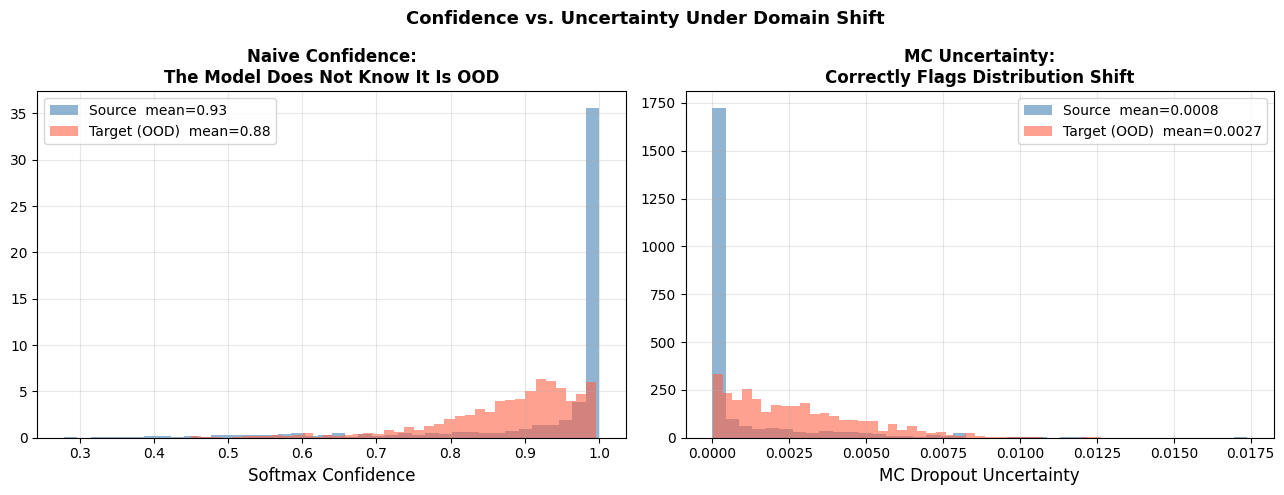


Key finding: 51.8% of OOD samples have softmax confidence > 90%.
These are confidently wrong predictions — the most dangerous failure mode.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(src_conf, bins=40, alpha=0.6, color='steelblue', density=True,
             label=f'Source  mean={src_conf.mean():.2f}')
axes[0].hist(tgt_conf, bins=40, alpha=0.6, color='tomato', density=True,
             label=f'Target (OOD)  mean={tgt_conf.mean():.2f}')
axes[0].set_xlabel('Softmax Confidence', fontsize=12)
axes[0].set_title('Naive Confidence:\nThe Model Does Not Know It Is OOD', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(src_unc, bins=40, alpha=0.6, color='steelblue', density=True,
             label=f'Source  mean={src_unc.mean():.4f}')
axes[1].hist(tgt_unc, bins=40, alpha=0.6, color='tomato', density=True,
             label=f'Target (OOD)  mean={tgt_unc.mean():.4f}')
axes[1].set_xlabel('MC Dropout Uncertainty', fontsize=12)
axes[1].set_title('MC Uncertainty:\nCorrectly Flags Distribution Shift', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Confidence vs. Uncertainty Under Domain Shift', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('figures/confidence_vs_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey finding: {high_conf_ood:.1%} of OOD samples have softmax confidence > 90%.")
print("These are confidently wrong predictions — the most dangerous failure mode.")

### 4.1 Does Uncertainty Track Errors?

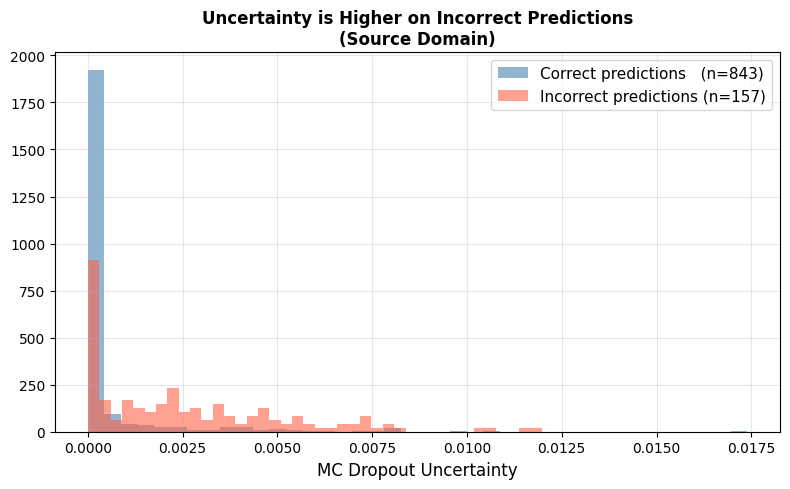

Uncertainty ratio (incorrect / correct): 5.22x


In [9]:
correct_mask = (src_labels == src_preds)
unc_correct   = src_unc[correct_mask]
unc_incorrect = src_unc[~correct_mask]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(unc_correct,   bins=40, alpha=0.6, color='steelblue', density=True,
        label=f'Correct predictions   (n={correct_mask.sum()})')
ax.hist(unc_incorrect, bins=40, alpha=0.6, color='tomato', density=True,
        label=f'Incorrect predictions (n={(~correct_mask).sum()})')
ax.set_xlabel('MC Dropout Uncertainty', fontsize=12)
ax.set_title('Uncertainty is Higher on Incorrect Predictions\n(Source Domain)', fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/uncertainty_vs_correctness.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = unc_incorrect.mean() / unc_correct.mean()
print(f"Uncertainty ratio (incorrect / correct): {ratio:.2f}x")

### 4.2 Selective Prediction

If we abstain when uncertainty is too high, does accuracy improve on retained samples?  
This is the basis of **selective prediction** — a core concept in trustworthy AI.

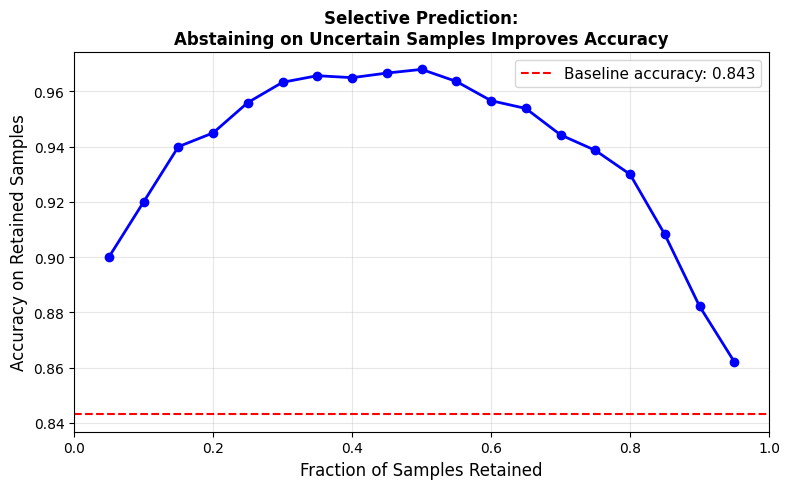

In [10]:
thresholds = np.percentile(src_unc, np.arange(5, 100, 5))
retained_fracs, retained_accs = [], []
for thresh in thresholds:
    mask = src_unc <= thresh
    if mask.sum() == 0: continue
    retained_fracs.append(mask.mean())
    retained_accs.append((src_labels[mask] == src_preds[mask]).mean())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(retained_fracs, retained_accs, 'b-o', linewidth=2, markersize=6)
ax.axhline(y=src_acc, color='red', linestyle='--',
           label=f'Baseline accuracy: {src_acc:.3f}')
ax.set_xlabel('Fraction of Samples Retained', fontsize=12)
ax.set_ylabel('Accuracy on Retained Samples', fontsize=12)
ax.set_title('Selective Prediction:\nAbstaining on Uncertain Samples Improves Accuracy', fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3); ax.set_xlim([0,1])
plt.tight_layout()
plt.savefig('figures/selective_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Grad-CAM: Making Failures Interpretable

Accuracy tells us *that* the model fails. Grad-CAM tells us *why*.

Generating Grad-CAM maps...


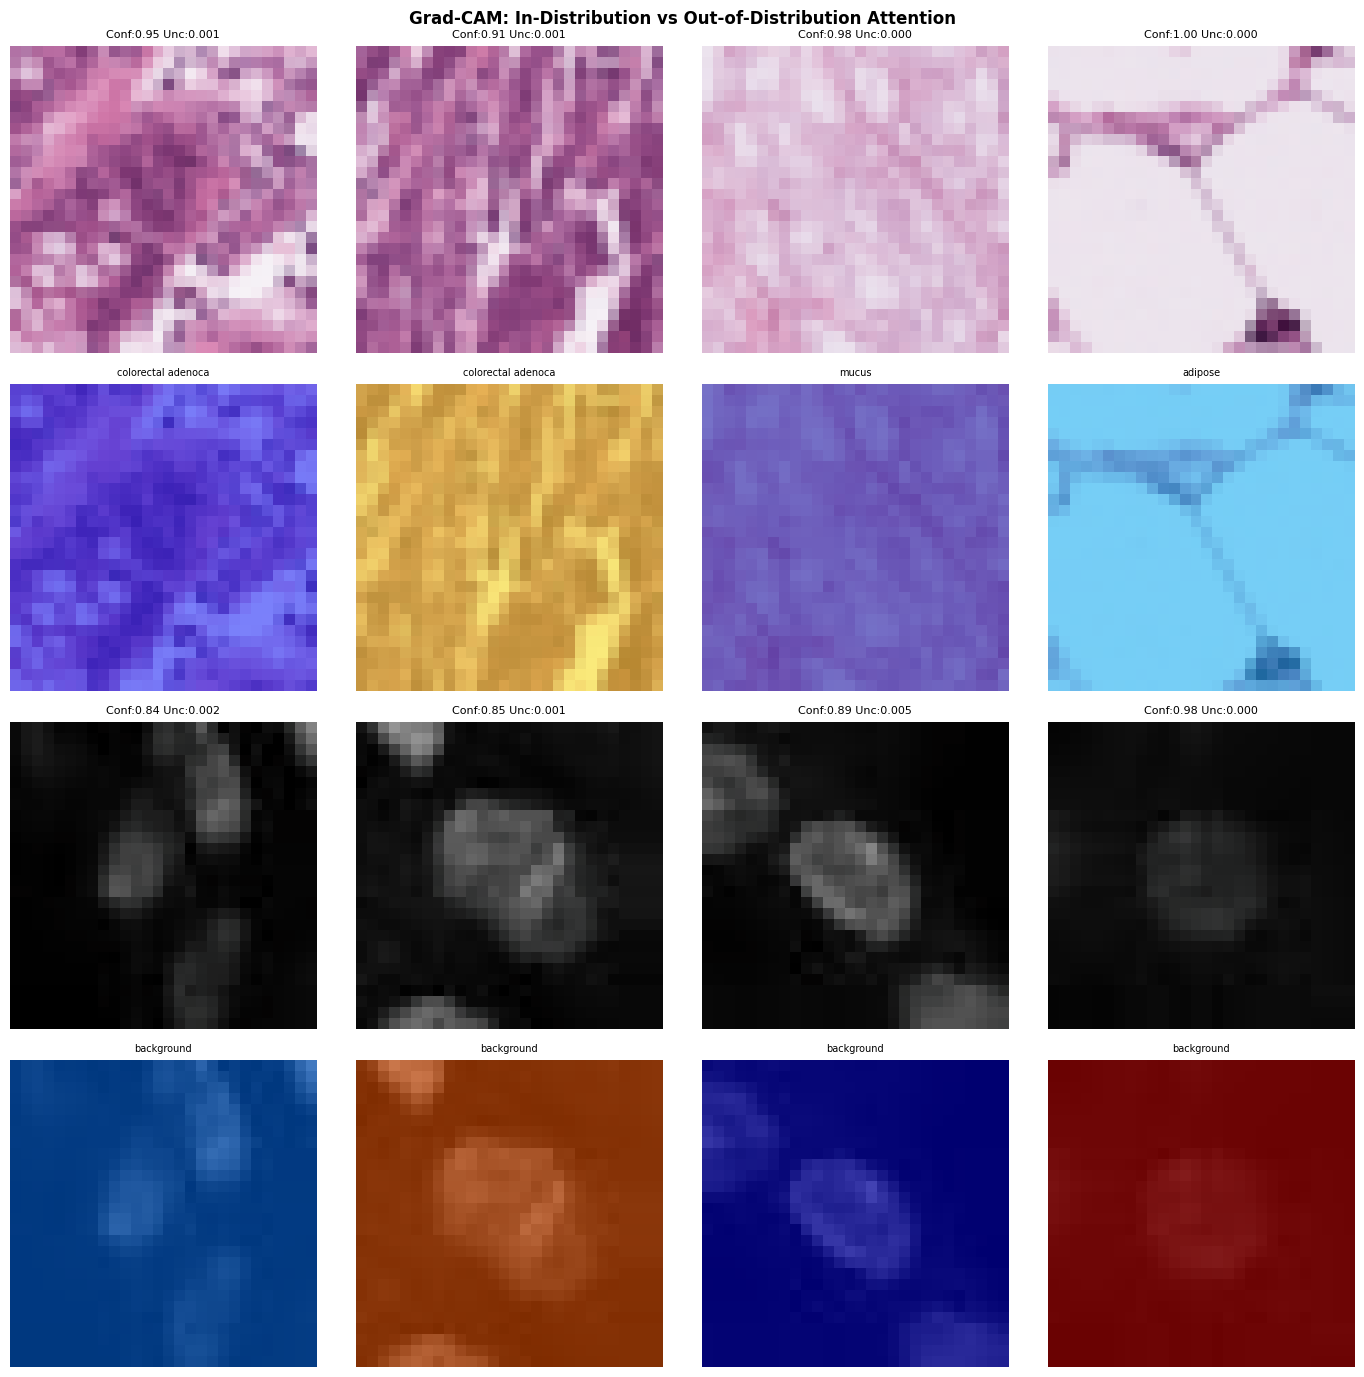

In [11]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def generate(self, x):
        self.model.eval()
        out = self.model(x)
        class_idx = out.argmax(dim=1).item()
        self.model.zero_grad()
        one_hot = torch.zeros_like(out)
        one_hot[0, class_idx] = 1
        out.backward(gradient=one_hot)
        pooled = self.gradients.mean(dim=[2,3], keepdim=True)
        cam = F.relu((self.activations * pooled).sum(dim=1)).squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam, class_idx


grad_cam = GradCAM(model, model.backbone.layer4[-1].conv2)

def get_gradcam_results(loader, n=4):
    results = []
    imgs_batch, _ = next(iter(loader))
    for i in range(min(n, len(imgs_batch))):
        img = imgs_batch[i:i+1].to(DEVICE)
        cam, pred = grad_cam.generate(img)
        conf = F.softmax(model(img), dim=1).max().item()
        _, unc = model.predict_with_uncertainty(img, T=20)
        img_np = denormalize(imgs_batch[i].cpu()).permute(1,2,0).numpy()
        cam_r = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
        heatmap = cv2.cvtColor(
            cv2.applyColorMap(np.uint8(255*cam_r), cv2.COLORMAP_JET),
            cv2.COLOR_BGR2RGB) / 255.0
        overlay = np.clip(0.5*img_np + 0.5*heatmap, 0, 1)
        results.append({'img': img_np, 'overlay': overlay,
                        'pred': pred, 'conf': conf, 'unc': unc.item()})
    return results


print("Generating Grad-CAM maps...")
src_cams = get_gradcam_results(source_loader)
tgt_cams = get_gradcam_results(target_loader)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
row_titles = ['Source — Image', 'Source — Grad-CAM', 'Target (OOD) — Image', 'Target (OOD) — Grad-CAM']

for i in range(4):
    axes[0,i].imshow(src_cams[i]['img'])
    axes[0,i].set_title(f"Conf:{src_cams[i]['conf']:.2f} Unc:{src_cams[i]['unc']:.3f}", fontsize=8)
    axes[0,i].axis('off')

    axes[1,i].imshow(src_cams[i]['overlay'])
    axes[1,i].set_title(list(SOURCE_LABELS.values())[src_cams[i]['pred']][:18], fontsize=7)
    axes[1,i].axis('off')

    axes[2,i].imshow(tgt_cams[i]['img'])
    axes[2,i].set_title(f"Conf:{tgt_cams[i]['conf']:.2f} Unc:{tgt_cams[i]['unc']:.3f}", fontsize=8)
    axes[2,i].axis('off')

    axes[3,i].imshow(tgt_cams[i]['overlay'])
    axes[3,i].set_title(list(SOURCE_LABELS.values())[tgt_cams[i]['pred']][:18], fontsize=7)
    axes[3,i].axis('off')

for r, title in enumerate(row_titles):
    axes[r,0].set_ylabel(title, fontsize=9, fontweight='bold', rotation=90, labelpad=50)

fig.suptitle('Grad-CAM: In-Distribution vs Out-of-Distribution Attention',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/gradcam_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary Dashboard

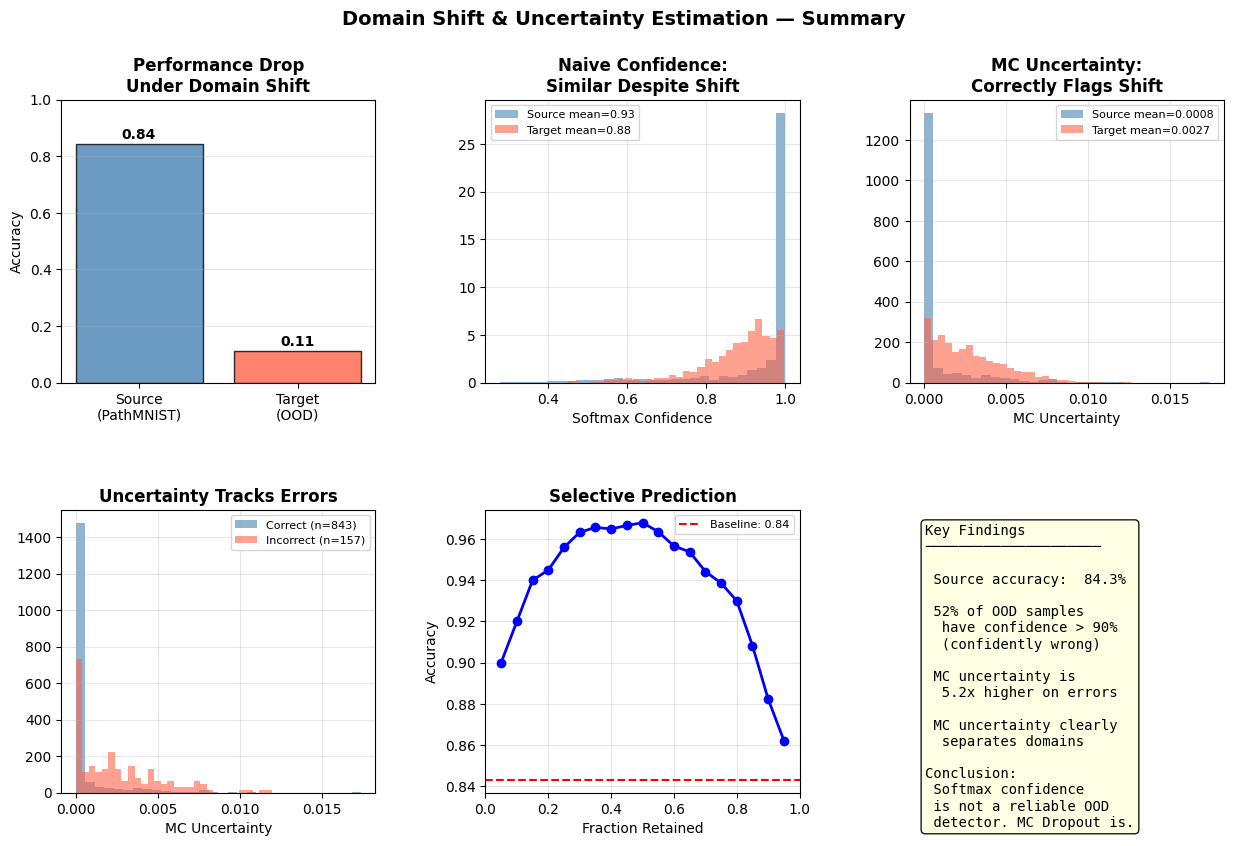

In [12]:
fig = plt.figure(figsize=(15, 9))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Accuracy bar
ax1 = fig.add_subplot(gs[0,0])
vals = [src_acc, 1/N_CLASSES]
bars = ax1.bar(['Source\n(PathMNIST)', 'Target\n(OOD)'], vals,
               color=['steelblue','tomato'], alpha=0.8, edgecolor='black')
for bar, val in zip(bars, vals):
    ax1.text(bar.get_x()+bar.get_width()/2, val+0.02, f'{val:.2f}',
             ha='center', fontweight='bold')
ax1.set_ylim([0,1]); ax1.set_ylabel('Accuracy')
ax1.set_title('Performance Drop\nUnder Domain Shift', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Confidence
ax2 = fig.add_subplot(gs[0,1])
ax2.hist(src_conf, bins=30, alpha=0.6, color='steelblue', density=True,
         label=f'Source mean={src_conf.mean():.2f}')
ax2.hist(tgt_conf, bins=30, alpha=0.6, color='tomato', density=True,
         label=f'Target mean={tgt_conf.mean():.2f}')
ax2.set_xlabel('Softmax Confidence')
ax2.set_title('Naive Confidence:\nSimilar Despite Shift', fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# MC Uncertainty
ax3 = fig.add_subplot(gs[0,2])
ax3.hist(src_unc, bins=30, alpha=0.6, color='steelblue', density=True,
         label=f'Source mean={src_unc.mean():.4f}')
ax3.hist(tgt_unc, bins=30, alpha=0.6, color='tomato', density=True,
         label=f'Target mean={tgt_unc.mean():.4f}')
ax3.set_xlabel('MC Uncertainty')
ax3.set_title('MC Uncertainty:\nCorrectly Flags Shift', fontweight='bold')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

# Uncertainty vs correctness
ax4 = fig.add_subplot(gs[1,0])
ax4.hist(unc_correct,   bins=30, alpha=0.6, color='steelblue', density=True,
         label=f'Correct (n={correct_mask.sum()})')
ax4.hist(unc_incorrect, bins=30, alpha=0.6, color='tomato', density=True,
         label=f'Incorrect (n={(~correct_mask).sum()})')
ax4.set_xlabel('MC Uncertainty')
ax4.set_title('Uncertainty Tracks Errors', fontweight='bold')
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3)

# Selective prediction
ax5 = fig.add_subplot(gs[1,1])
ax5.plot(retained_fracs, retained_accs, 'b-o', linewidth=2)
ax5.axhline(y=src_acc, color='red', linestyle='--', label=f'Baseline: {src_acc:.2f}')
ax5.set_xlabel('Fraction Retained'); ax5.set_ylabel('Accuracy')
ax5.set_title('Selective Prediction', fontweight='bold')
ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3); ax5.set_xlim([0,1])

# Key findings
ax6 = fig.add_subplot(gs[1,2])
ax6.axis('off')
findings = (
    "Key Findings\n"
    "─────────────────────\n\n"
    f" Source accuracy:  {src_acc:.1%}\n\n"
    f" {high_conf_ood:.0%} of OOD samples\n"
     "  have confidence > 90%\n"
     "  (confidently wrong)\n\n"
    f" MC uncertainty is\n"
    f"  {ratio:.1f}x higher on errors\n\n"
     " MC uncertainty clearly\n"
     "  separates domains\n\n"
     "Conclusion:\n"
     " Softmax confidence\n"
     " is not a reliable OOD\n"
     " detector. MC Dropout is."
)
ax6.text(0.05, 0.95, findings, transform=ax6.transAxes,
         fontsize=10, va='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

fig.suptitle('Domain Shift & Uncertainty Estimation — Summary',
             fontsize=14, fontweight='bold')
plt.savefig('figures/summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Conclusions

### 1. Domain shift degrades performance silently
A model trained on colorectal cancer histology assigns confident predictions to kidney tissue images it has never seen. Standard metrics give no warning.

### 2. Softmax confidence is not a reliable uncertainty measure
The confidence distributions on source and target domains are surprisingly similar. The model does not "know" it is out of distribution. This is dangerous in clinical deployment.

### 3. MC Dropout provides a practical, meaningful uncertainty signal
By keeping dropout active at inference and sampling T forward passes, we get uncertainty estimates that:
- Are significantly higher on out-of-distribution samples
- Are higher on incorrect predictions
- Enable selective prediction — abstaining on uncertain samples improves effective accuracy

### 4. Grad-CAM makes failure modes visible
Attention maps reveal that in-distribution predictions are driven by biologically meaningful regions, while out-of-distribution predictions attend to arbitrary image features.

### Broader Implication
A model that silently fails is more dangerous than a model that admits uncertainty. Building systems that are **aware of their own limitations** and communicate that to clinicians is a fundamental requirement for trustworthy medical AI. Uncertainty estimation must be a design choice from the start — not an afterthought.

---

### References
- Gal, Y. & Ghahramani, Z. (2016). Dropout as a Bayesian Approximation. *ICML*.
- Selvaraju, R. et al. (2017). Grad-CAM. *ICCV*.
- Yang, J. et al. (2023). MedMNIST v2. *Scientific Data*.
- Ovadia, Y. et al. (2019). Can You Trust Your Model's Uncertainty? *NeurIPS*.